# Time Value of Money and Investment Basics

Visualize compound interest and evaluate a project using NPV and IRR.

## Goals

- See how money grows at different rates over time
- Calculate NPV and IRR for a $500k project
- Understand the break-even discount rate


## Compound Interest

Shows the dramatic effect of compounding over time at different rates. Starting with $10k, higher rates lead to exponential growth.


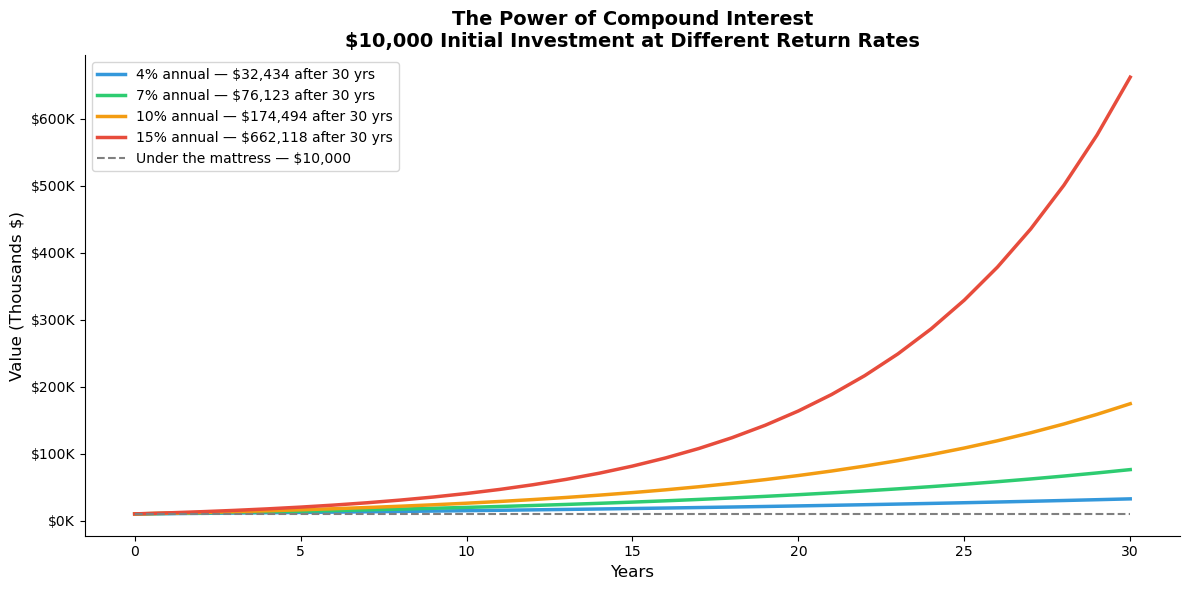

In [1]:
import numpy as np
import numpy_financial as npf
import matplotlib.pyplot as plt

# Compound Interest Visualizer
# Start with $10,000, compare different annual return rates over 30 years
INITIAL_INVESTMENT = 10_000
YEARS = np.arange(0, 31)
RATES = [0.04, 0.07, 0.10, 0.15]
COLORS = ['#3498db', '#2ecc71', '#f39c12', '#e74c3c']

fig, ax = plt.subplots(figsize=(12, 6))

for rate, color in zip(RATES, COLORS):
    # Compound interest formula: FV = PV * (1 + r)^n
    future_values = INITIAL_INVESTMENT * (1 + rate) ** YEARS
    ax.plot(YEARS, future_values / 1000, color=color, linewidth=2.5, 
            label=f'{rate*100:.0f}% annual — ${future_values[-1]:,.0f} after 30 yrs')

# Add simple savings (0% return) as baseline
ax.plot(YEARS, [INITIAL_INVESTMENT/1000] * len(YEARS), color='gray', linewidth=1.5, 
        linestyle='--', label=f'Under the mattress — ${INITIAL_INVESTMENT:,}')

ax.set_xlabel('Years', fontsize=12)
ax.set_ylabel('Value (Thousands $)', fontsize=12)
ax.set_title('The Power of Compound Interest\n$10,000 Initial Investment at Different Return Rates', fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='upper left')
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:.0f}K'))

plt.tight_layout()
plt.savefig('../data/compound_interest.png', dpi=150, bbox_inches='tight')
plt.show()

## Net Present Value and IRR

NPV tells you the present value of future cash flows minus the initial cost. IRR is the discount rate that makes NPV zero — the project's effective return.

Here we evaluate a $500k project with given cash flows.


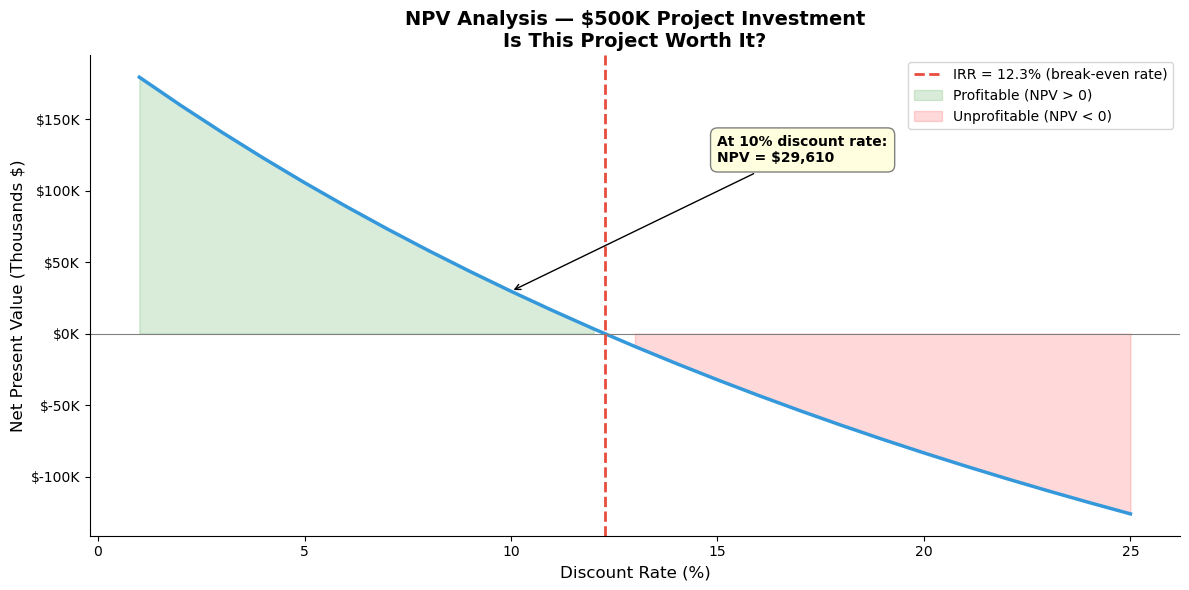

In [2]:
# Net Present Value — Should we invest in this project?
# Scenario: A project costs $500K upfront but generates cash over 5 years
INITIAL_COST = -500_000
ANNUAL_CASH_FLOWS = [120_000, 150_000, 160_000, 140_000, 130_000]
ALL_CASH_FLOWS = [INITIAL_COST] + ANNUAL_CASH_FLOWS

# Calculate NPV at different discount rates
DISCOUNT_RATES = np.arange(0.01, 0.26, 0.01)
NPVS = [npf.npv(rate, ALL_CASH_FLOWS) for rate in DISCOUNT_RATES]

# Find the IRR — the rate where NPV = 0
IRR = npf.irr(ALL_CASH_FLOWS)

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(DISCOUNT_RATES * 100, [n/1000 for n in NPVS], color='#3498db', linewidth=2.5)
ax.axhline(y=0, color='gray', linestyle='-', linewidth=0.8)
ax.axvline(x=IRR*100, color='#e74c3c', linestyle='--', linewidth=2, 
           label=f'IRR = {IRR*100:.1f}% (break-even rate)')

# Shade profitable zone green, unprofitable red
ax.fill_between(DISCOUNT_RATES * 100, [n/1000 for n in NPVS], 0, 
                where=[n > 0 for n in NPVS], alpha=0.15, color='green', label='Profitable (NPV > 0)')
ax.fill_between(DISCOUNT_RATES * 100, [n/1000 for n in NPVS], 0, 
                where=[n <= 0 for n in NPVS], alpha=0.15, color='red', label='Unprofitable (NPV < 0)')

# Annotate the scenario
ax.annotate(f'At 10% discount rate:\nNPV = ${npf.npv(0.10, ALL_CASH_FLOWS):,.0f}', 
            xy=(10, npf.npv(0.10, ALL_CASH_FLOWS)/1000), xytext=(15, 120),
            arrowprops=dict(arrowstyle='->', color='black'), fontsize=10, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='lightyellow', edgecolor='gray'))

ax.set_xlabel('Discount Rate (%)', fontsize=12)
ax.set_ylabel('Net Present Value (Thousands $)', fontsize=12)
ax.set_title('NPV Analysis — $500K Project Investment\nIs This Project Worth It?', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:.0f}K'))

plt.tight_layout()
plt.savefig('../data/npv_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## Try This (to drill the concepts)

- Change `INITIAL_INVESTMENT` or one of the `RATES` and re-run the compound chart. How does the gap between 4% and 15% change?
- In the NPV section, modify `ANNUAL_CASH_FLOWS` and observe how the IRR and profitable zone shift.
- What discount rate makes this project exactly break-even?
